# Import Libraries

In [260]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read in Data

In [261]:
Demand = pd.read_excel("../../data/raw/battery/Qtr Hourly Grid Data 2025.xlsx",
                       sheet_name = 'System Data',
                        usecols = ['DateTime', 'TCF 0.3', 'TCF 0.5', 'TCF 0.7'])

Demand["DateTime"] = pd.to_datetime(Demand["DateTime"])
Demand = Demand.set_index("DateTime")

Hourly_Demand = Demand.resample("1h").mean()

Hourly_Demand.head()

,TCF 0.3,TCF 0.5,TCF 0.7
DateTime,,,
2025-01-01 00:00:00,29.810998,49.684996,69.558995
2025-01-01 01:00:00,28.720943,47.868238,67.015533
2025-01-01 02:00:00,27.964897,46.608161,65.251425
2025-01-01 03:00:00,26.980106,44.966843,62.953580
2025-01-01 04:00:00,25.928406,43.214010,60.499615


In [262]:
price_data = pd.read_csv(r"../../data/raw/battery/historical-irish-electricity-prices.csv")
price_data['Timestamp_UTC'] = pd.to_datetime(price_data['Timestamp_UTC'])
price_data = price_data[price_data['Timestamp_UTC'] >= pd.Timestamp.now() - pd.Timedelta(days=365)]


price_data['Date'] = price_data['Timestamp_UTC'].dt.date

In [263]:
# Find most and least expensive 4 hour electricity stretches for each day of last year

##### This cell leads nowhere #####
def daily_window_hours(group):
    prices = group['Price'].values
    hours  = group['Timestamp_UTC'].dt.hour.values
    n = 4
    if len(prices) < n:
        return pd.Series({'cheap_start': np.nan, 'expensive_start': np.nan})
    avgs = [prices[i:i+n].mean() for i in range(len(prices) - n + 1)]
    low_i  = int(np.argmin(avgs))
    high_i = int(np.argmax(avgs))
    return pd.Series({'cheap_start': hours[low_i], 'expensive_start': hours[high_i]})

windows = price_data.groupby('Date').apply(daily_window_hours, include_groups=False)


In [264]:
L1 = pd.read_excel("../../data/processed/exports/hourly_availability_by_node_phase3.xlsx", 
                   sheet_name='GalwayP3', 
                   usecols=['MWh Available']) # Skips the first 3 rows to make 'Row Labels' the header


L1.head()

,MWh Available
0,500.0
1,500.0
2,500.0
3,500.0
4,500.0


In [265]:
Cork_Constraints = pd.read_excel("../../data/processed/exports/curtailment/new_farms_hourly_constraints_phase3_60-100.xlsx",
                            sheet_name='hourly',
                            usecols = ['curtailment_hat_mwh','node_id'])

Cork_Constraints = Cork_Constraints[Cork_Constraints['node_id'] == "GalwayP3"]

Cork_Constraints.tail(5)

,node_id,curtailment_hat_mwh
17515,GalwayP3,0.0
17516,GalwayP3,0.0
17517,GalwayP3,0.0
17518,GalwayP3,0.0
17519,GalwayP3,0.0


In [266]:
Hourly_Demand['L1'] = L1['MWh Available'].values

Hourly_Demand.head()

,TCF 0.3,TCF 0.5,TCF 0.7,L1
DateTime,,,,
2025-01-01 00:00:00,29.810998,49.684996,69.558995,500.0
2025-01-01 01:00:00,28.720943,47.868238,67.015533,500.0
2025-01-01 02:00:00,27.964897,46.608161,65.251425,500.0
2025-01-01 03:00:00,26.980106,44.966843,62.953580,500.0
2025-01-01 04:00:00,25.928406,43.214010,60.499615,500.0


In [267]:
Hourly_Demand['TCF 1.0'] = Hourly_Demand['TCF 0.5']*4*0.6*4/3

Hourly_Demand.head()

,TCF 0.3,TCF 0.5,TCF 0.7,L1,TCF 1.0
DateTime,,,,,
2025-01-01 00:00:00,29.810998,49.684996,69.558995,500.0,158.991988
2025-01-01 01:00:00,28.720943,47.868238,67.015533,500.0,153.178362
2025-01-01 02:00:00,27.964897,46.608161,65.251425,500.0,149.146115
2025-01-01 03:00:00,26.980106,44.966843,62.953580,500.0,143.893897
2025-01-01 04:00:00,25.928406,43.214010,60.499615,500.0,138.284833


In [268]:
Hourly_Demand['Constraints'] = Cork_Constraints['curtailment_hat_mwh'].values

Hourly_Demand.head()

,TCF 0.3,TCF 0.5,TCF 0.7,L1,TCF 1.0,Constraints
DateTime,,,,,,
2025-01-01 00:00:00,29.810998,49.684996,69.558995,500.0,158.991988,80.0
2025-01-01 01:00:00,28.720943,47.868238,67.015533,500.0,153.178362,80.0
2025-01-01 02:00:00,27.964897,46.608161,65.251425,500.0,149.146115,80.0
2025-01-01 03:00:00,26.980106,44.966843,62.953580,500.0,143.893897,80.0
2025-01-01 04:00:00,25.928406,43.214010,60.499615,500.0,138.284833,80.0


In [269]:
Hourly_Demand['TCF 1.0'].max()

np.float64(272.4576900323836)

In [270]:
Hourly_Demand['TCF 1.0'].sum()/(8760*450)

np.float64(0.39996185029640424)

In [271]:
Hourly_Demand['TCF 1.0'].mean()

np.float64(180.00338096454226)

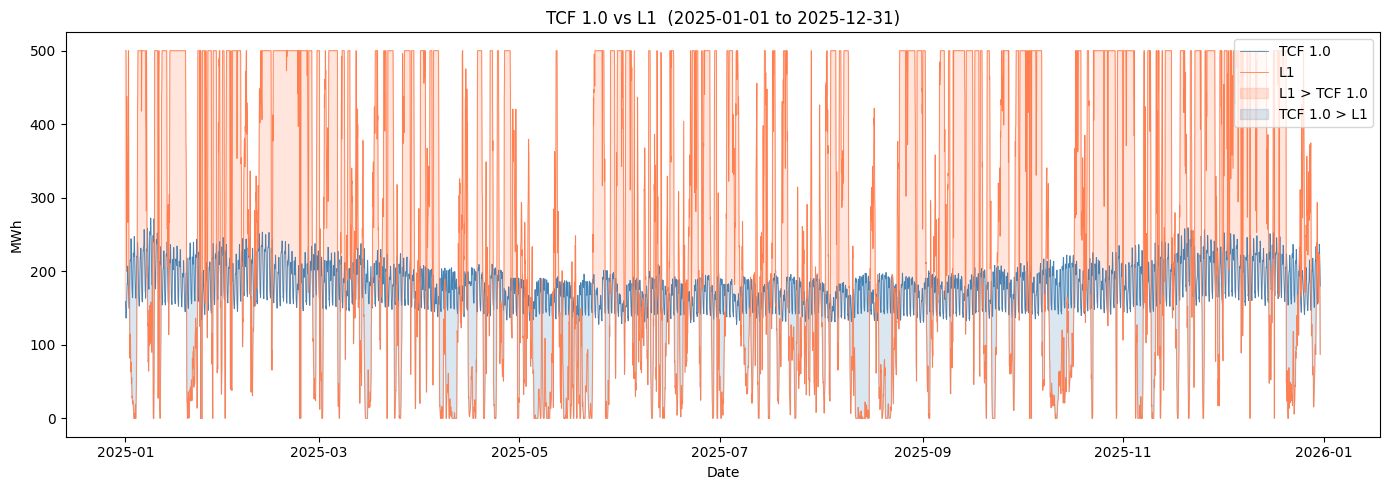

In [272]:
# === CHANGE THESE DATES TO ADJUST THE PLOT RANGE ===
plot_start = '2025-01-01'
plot_end   = '2025-12-31'
# ====================================================

mask = (Hourly_Demand.index >= plot_start) & (Hourly_Demand.index <= plot_end)
plot_data = Hourly_Demand.loc[mask]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(plot_data.index, plot_data['TCF 1.0'], linewidth=0.6, color='steelblue', label='TCF 1.0')
ax.plot(plot_data.index, plot_data['L1'], linewidth=0.6, color='coral', label='L1')
ax.fill_between(plot_data.index, plot_data['TCF 1.0'], plot_data['L1'], 
                where=plot_data['L1'] > plot_data['TCF 1.0'], alpha=0.2, color='coral', label='L1 > TCF 1.0')
ax.fill_between(plot_data.index, plot_data['TCF 1.0'], plot_data['L1'], 
                where=plot_data['L1'] <= plot_data['TCF 1.0'], alpha=0.2, color='steelblue', label='TCF 1.0 > L1')
ax.set_title(f'TCF 1.0 vs L1  ({plot_start} to {plot_end})')
ax.set_xlabel('Date')
ax.set_ylabel('MWh')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Wind Curtailment Data


# Manual Inputs

In [273]:
### Assumptions ###
# Elec price = €150/MWh (15c/kWh)
# Minimum battery charge 15%
# 90% RTE
# Battery power = 1/20 generator power, 4 hour capacity
# Capex €300k/MWh
# Opex 2% of capex

# Battery Characteristics

Batt_Size = 50   # Battery size in MW
Batt_Cap = 2       # Battery Capacity in hours
RTE = 0.90          # Round trip efficiency
init_charge = 0.7   # Initial battery charge


In [274]:
# Controls

min_charge = 0.15   # Minimum allowable battery charge

MIC = 0          # Maximum Import Capacity (kW)

TBCharging = False    # Time-based charging enabled
PBCharging = True    # Production-based (excess) charging enabled

IncludeCurtailment = True  # Include curtailment constraints (False to ignore)
IncludeArbitrage   = True  # Price-based arbitrage: cheap grid charging + peak selling

# Arbitrage parameters (only active when IncludeArbitrage = True)
ArbitrageChargeWindow    = [21, 17]  # Grid charge window: 22:00 prev day → 12:00 today
ArbitrageDischargeWindow = [17, 21]  # Sell window: 17:00–21:00
ArbitrageChargeDuration  = Batt_Cap  # Cheapest contiguous hours to purchase

charge_times = [[22,7],         # Charging start and stop
                [7,22]]         # Discharging start and stop

In [275]:
# Financials

elec_price = 100          # €/MWh

grid_import_adder = 30    # €/MWh additional cost on grid imports (3c/kWh)

DS3_FFR_rate = 2.0        # €/MW/hour for DS3 FFR upward availability

capex = 200000            # CapEx in €/MWh
opex = capex*0.02        # OpEx in €/MWh

# Create Inputs Dataframe

In [276]:
df = pd.DataFrame({
    'Time Stamp': Hourly_Demand.index,
    'Load (MWh)': Hourly_Demand['TCF 1.0'],
    'Generation (MWh)': Hourly_Demand['L1'],
    'Constraints': Hourly_Demand['Constraints']
})

df

,Time Stamp,Load (MWh),Generation (MWh),Constraints
DateTime,,,,
2025-01-01 00:00:00,2025-01-01 00:00:00,158.991988,500.000000,80.0
2025-01-01 01:00:00,2025-01-01 01:00:00,153.178362,500.000000,80.0
2025-01-01 02:00:00,2025-01-01 02:00:00,149.146115,500.000000,80.0
2025-01-01 03:00:00,2025-01-01 03:00:00,143.893897,500.000000,80.0
2025-01-01 04:00:00,2025-01-01 04:00:00,138.284833,500.000000,80.0
...,...,...,...,...
2025-12-31 19:00:00,2025-12-31 19:00:00,215.518739,0.000000,0.0
2025-12-31 20:00:00,2025-12-31 20:00:00,202.497366,11.928901,0.0
2025-12-31 21:00:00,2025-12-31 21:00:00,192.344535,35.795268,0.0


In [277]:
print(f"{df['Generation (MWh)'].sum():,}")

2,448,838.748841577


In [278]:
# Calculates remaining load after generation

rem_load = np.maximum(0, df['Load (MWh)'] - df['Generation (MWh)'])
df['Remaining Load'] = rem_load

In [279]:
# Calculates Excess Generation

excess = np.maximum(0, df['Generation (MWh)'] - df['Load (MWh)'])
df['Excess'] = excess

In [280]:
# Initial Battery Charge

init_charge_MWh = init_charge*Batt_Cap*Batt_Size
init_charge_MWh

70.0

In [281]:
# Derived Battery Constants

Batt_Loss = (1 - RTE) / 2                     # Battery Loss per charge/discharge
Max_Charge = Batt_Size * Batt_Cap             # max battery energy (MWh)
Min_Charge_MWh = Max_Charge * min_charge      # min battery energy (MWh)
Batt_Pow_half = Batt_Size                 

In [282]:
df['Load (MWh)'] = df['Load (MWh)'].fillna(0)

# Time Series Calculations

In [283]:
# ============================================================
# Build price_arr: hourly prices aligned to simulation year
# Prices matched by month + day-of-month + hour so that, e.g.,
# the simulation hour 2025-02-02 01:00 uses the price for 02-02 01:00
# from the price data (regardless of which year it comes from).
# The most recent year's price is used for each month/day/hour.
# ============================================================

price_data['_month'] = price_data['Timestamp_UTC'].dt.month
price_data['_day']   = price_data['Timestamp_UTC'].dt.day
price_data['_hour']  = price_data['Timestamp_UTC'].dt.hour

price_lookup = (
    price_data
    .sort_values('Timestamp_UTC')
    .drop_duplicates(subset=['_month', '_day', '_hour'], keep='last')
    .set_index(['_month', '_day', '_hour'])['Price']
)

price_arr = np.array([
    price_lookup.get((ts.month, ts.day, ts.hour), elec_price)
    for ts in df.index
])

if not IncludeCurtailment:
    df['Constraints'] = np.zeros(len(df))

# Wind consumed on-site = min(generation, load - curtailment), clamped to 0
# Curtailment is absorbed by the battery, so excluded from wind serving demand
wind_consumed_arr   = np.maximum(
    0,
    np.minimum(df['Generation (MWh)'].values,
               df['Load (MWh)'].values - df['Constraints'].values)
)
wind_revenue_arr    = wind_consumed_arr * price_arr
total_wind_revenue  = wind_revenue_arr.sum()

print(f"Price array: {len(price_arr)} hours, "
      f"mean €{price_arr.mean():.2f}/MWh, "
      f"min €{price_arr.min():.2f}/MWh, "
      f"max €{price_arr.max():.2f}/MWh")
print(f"Total wind revenue (at spot price): €{total_wind_revenue:,.0f}")

Price array: 8760 hours, mean €109.15/MWh, min €-23.50/MWh, max €465.77/MWh
Total wind revenue (at spot price): €95,537,864


In [284]:
print(f"{wind_consumed_arr.sum():,}")

881,518.0964889218


In [285]:
# ============================================================
# Day-ahead grid charging schedule pre-computation
# ============================================================

def compute_grid_charge_schedule(Max_Charge_v, Min_Charge_MWh_v, Batt_Pow_half_v,
                                  one_minus_loss_v, ex_arr, con_arr, h_arr, p_arr):
    """
    Pre-compute day-ahead grid charging schedule for price arbitrage.
    Returns float array (8760,) with MWh of scheduled grid charging per hour.
    Only charges the battery from the grid when wind alone can't fill it,
    using the cheapest ArbitrageChargeDuration-hour contiguous window
    between 21:00 the previous day and 17:00 the current day.
    """
    n_v      = len(ex_arr)
    n_slots  = ArbitrageChargeDuration
    d_s, d_e = ArbitrageDischargeWindow   # e.g. 17, 21

    # --- Pass 1: forward-predict SOC without grid charging ---
    pred_soc = np.empty(n_v + 1)
    pred_soc[0] = init_charge * Max_Charge_v

    for i in range(n_v):
        soc = pred_soc[i]
        ex  = ex_arr[i]
        con = con_arr[i]
        h   = h_arr[i]

        # Natural charging: curtailment-based or excess-based
        charge = 0.0
        if con > 0 and soc < Max_Charge_v:
            charge = min(Batt_Pow_half_v, (Max_Charge_v - soc) / one_minus_loss_v)
        elif ex > 0 and PBCharging and soc < Max_Charge_v:
            charge = min(ex, Batt_Pow_half_v, (Max_Charge_v - soc) / one_minus_loss_v)

        # Predicted discharge: only in arbitrage sell window
        discharge = 0.0
        if d_s <= h < d_e and soc > Min_Charge_MWh_v and con == 0:
            discharge = min(soc - Min_Charge_MWh_v, Batt_Pow_half_v)

        pred_soc[i + 1] = soc + charge * one_minus_loss_v - discharge

    # --- Pass 2: for each day find cheapest grid-charge window ---
    schedule = np.zeros(n_v)

    for d in range(365):
        # Natural fill window: 21:00 day d-1 → 17:00 day d
        # Grid charge window: same range (buy cheapest power between discharge cycles)
        d_s_hour, d_e_hour = ArbitrageDischargeWindow  # 17, 21

        if d == 0:
            fill_start = 0
            w_start    = 0
        else:
            fill_start = (d - 1) * 24 + d_e_hour      # 21:00 prev day
            w_start    = fill_start

        fill_end = min(d * 24 + d_s_hour, n_v)         # 17:00 today
        w_end    = fill_end

        if w_end - w_start < n_slots:
            continue

        # SOC at start of window (post-discharge)
        soc_at_start = pred_soc[fill_start]

        # Natural fill: wind/curtailment charging between 21:00(d-1) and 17:00(d)
        natural_fill = 0.0
        for i in range(fill_start, fill_end):
            con = con_arr[i]
            ex  = ex_arr[i]
            if con > 0:
                natural_fill += min(con, Batt_Pow_half_v)
            elif ex > 0 and PBCharging:
                natural_fill += min(ex, Batt_Pow_half_v)

        soc_after_natural = min(soc_at_start + natural_fill * one_minus_loss_v, Max_Charge_v)
        remaining         = Max_Charge_v - soc_after_natural

        if remaining <= 0:
            continue

        # Sliding window: cheapest n_slots-hour contiguous block within charge window
        wp     = p_arr[w_start:w_end]
        n_w    = len(wp)
        best_avg = np.inf
        best_k   = 0
        for k in range(n_w - n_slots + 1):
            avg = wp[k:k + n_slots].mean()
            if avg < best_avg:
                best_avg = avg
                best_k   = k

        grid_needed    = remaining / one_minus_loss_v
        power_per_hour = min(grid_needed / n_slots, Batt_Pow_half_v)

        for k in range(n_slots):
            idx = w_start + best_k + k
            if idx < n_v:
                schedule[idx] += power_per_hour

    return schedule


# Compute schedule (or zeros if arbitrage disabled)
if IncludeArbitrage:
    _ex_sched  = df['Excess'].values
    _con_sched = df['Constraints'].values.copy()
    if not IncludeCurtailment:
        _con_sched[:] = 0.0
    _h_sched = df.index.hour.values

    grid_charge_schedule_arr = compute_grid_charge_schedule(
        Max_Charge, Min_Charge_MWh, Batt_Pow_half, 1 - Batt_Loss,
        _ex_sched, _con_sched, _h_sched, price_arr
    )
    print(f"Grid charge schedule: {(grid_charge_schedule_arr > 0).sum()} hours, "
          f"{grid_charge_schedule_arr.sum():.1f} MWh planned grid charge")
else:
    grid_charge_schedule_arr = np.zeros(len(df))
    print("Arbitrage disabled — grid charge schedule set to zero")

Grid charge schedule: 150 hours, 6106.6 MWh planned grid charge


In [286]:
import time
start_time = time.time()


# Parse timestamps once for both hour and month
parsed_dt = pd.to_datetime(df['Time Stamp'], format='%m-%d %H:%M')
hours     = parsed_dt.dt.hour.values
month_arr = parsed_dt.dt.month.values

# Charging timing logic
c_start, c_end = charge_times[0]

if TBCharging:
    if c_start <= c_end:
            charging_arr = ((hours >= c_start) & (hours < c_end)).astype(int)
    else:
            charging_arr = ((hours >= c_start) | (hours < c_end)).astype(int)

    # Discharging timing logic
    d_start, d_end = charge_times[1]
    if d_start <= d_end:
            discharging_arr = ((hours >= d_start) & (hours < d_end)).astype(int)
    else:
            discharging_arr = ((hours >= d_start) | (hours < d_end)).astype(int)
else:
    charging_arr    = np.zeros(len(Hourly_Demand))
    discharging_arr = np.ones(len(Hourly_Demand))

# When arbitrage is enabled, restrict discharging to the peak sell window (17:00–21:00)
if IncludeArbitrage:
    d_start, d_end  = ArbitrageDischargeWindow   # 17, 21
    discharging_arr = ((hours >= d_start) & (hours < d_end)).astype(int)

# Remaining load and excess as numpy arrays
rem_load_arr    = df['Remaining Load'].values
excess_arr      = df['Excess'].values
constraints_arr = df['Constraints'].values

# Zero out constraints if curtailment is disabled
if not IncludeCurtailment:
    constraints_arr = np.zeros_like(constraints_arr)
    df['Constraints'] = constraints_arr

# Overproduction and combined charge command
exbased_arr     = ((excess_arr > 0) & PBCharging).astype(int)
charge_cmd1_arr = ((charging_arr == 1) | (exbased_arr == 1)).astype(int)

# Pre-compute loop constants
one_minus_loss = 1 - Batt_Loss
half_MIC       = MIC / 2

# === Sequential simulation ===
n = len(df)
charge_status       = np.zeros(n)
max_charge_amt      = np.zeros(n)
max_discharge_amt   = np.zeros(n)
max_grid_charge_amt = np.zeros(n)   # Grid electricity drawn for arbitrage charging

prev_charge = init_charge_MWh

for i in range(n):
    rem_load    = rem_load_arr[i]
    excess      = excess_arr[i]
    charging    = charging_arr[i]
    exbased     = exbased_arr[i]
    charge_cmd1 = charge_cmd1_arr[i]
    discharging = discharging_arr[i]
    constraint  = constraints_arr[i]

    has_constraint = constraint > 0

    # Max allowable discharge — blocked when constraints are active
    Max_dis = 0
    if not has_constraint:
        DC_Cap = prev_charge > Min_Charge_MWh
        if discharging and DC_Cap:
            spare_dis = prev_charge - Min_Charge_MWh
            Max_dis = min(spare_dis, Batt_Pow_half, rem_load)
            if Max_dis < 0:
                Max_dis = 0
    max_discharge_amt[i] = Max_dis

    # Max allowable charge (curtailment / time-based / excess)
    Max_C = 0
    if has_constraint and prev_charge < Max_Charge:
        # Constraint-based charging
        available_space = (Max_Charge - prev_charge) / one_minus_loss
        #Max_C = min(constraint, Batt_Pow_half, available_space)
        Max_C = min(Batt_Pow_half, available_space)
        if Max_C < 0:
            Max_C = 0
    elif charge_cmd1 and prev_charge < Max_Charge:
        DC_Cap = prev_charge > Min_Charge_MWh
        # Time-based charge capacity
        TCharge_Cap = min(
            (Max_Charge - (prev_charge - Max_dis)) / one_minus_loss,
            abs(half_MIC - rem_load)
        ) * charging
        # Excess-based charge capacity
        SCharge_Cap = min(
            (Max_Charge - prev_charge) / one_minus_loss,
            excess
        ) * exbased
        Max_C = min(TCharge_Cap + SCharge_Cap, Batt_Pow_half)
        if Max_C < 0:
            Max_C = 0

    # Additive grid charging from pre-computed arbitrage schedule
    # (Does not fire during constrained hours because grid charge is blocked when
    # constraint > 0 forces the battery to absorb curtailed wind at full power)
    grid_c = grid_charge_schedule_arr[i]
    if grid_c > 0 and prev_charge < Max_Charge:
        available_space = (Max_Charge - prev_charge) / one_minus_loss
        extra = max(min(grid_c, available_space - Max_C), 0.0)
        Max_C += extra
        max_grid_charge_amt[i] = extra

    max_charge_amt[i] = Max_C   # final value (includes grid charging)

    # Update battery SOC
    prev_charge = prev_charge + Max_C * one_minus_loss - Max_dis
    charge_status[i] = prev_charge

# Post-loop vectorised calculations
net_charge = max_charge_amt * one_minus_loss - max_discharge_amt
energy_io  = max_charge_amt - max_discharge_amt * one_minus_loss

# Grid import: only battery arbitrage charging (not demand shortfalls)
# Grid export: excess generation not absorbed by wind/curtailment charging
wind_charge_arr = max_charge_amt - max_grid_charge_amt
grid_import     = max_grid_charge_amt
grid_export     = np.maximum(0, excess_arr - wind_charge_arr)

battery_action = np.where(
    net_charge > 0, 'CHARGING',
    np.where(net_charge < 0, 'DISCHARGING', 'NO ACTIVITY')
)

# === DS3 FFR Upward Availability ===
# Available MW = discharge headroom not already used for arbitrage discharge.
# Only counts hours when the battery is charged but not actively discharging,
# i.e. the battery is idle or charging while waiting for peak hours.
ds3_discharge_headroom = np.maximum(0, charge_status - Min_Charge_MWh)
ds3_available_mw       = np.minimum(Batt_Pow_half, ds3_discharge_headroom) - max_discharge_amt
ds3_available_mw       = np.maximum(0, ds3_available_mw)

# Assign results to dataframe
df['Net Charge']        = net_charge
df['Charge Status']     = charge_status
df['Battery Action']    = battery_action
df['Energy Flow']       = energy_io
df['Grid Import']       = grid_import
df['Grid Export']       = grid_export
df['Grid Charge (MWh)'] = max_grid_charge_amt
df['DS3 Available (MW)'] = ds3_available_mw

elapsed = time.time() - start_time
print(f"Time series calculation completed in {elapsed:.3f} seconds")
print(f"DS3 FFR availability: {(ds3_available_mw > 0).sum()} hours, "
      f"avg {ds3_available_mw[ds3_available_mw > 0].mean():.1f} MW when available")

Time series calculation completed in 0.033 seconds
DS3 FFR availability: 7273 hours, avg 49.0 MW when available


# Table

In [287]:
pd.set_option('display.max_rows',100)
display(df[0:10])

,Time Stamp,Load (MWh),Generation (MWh),Constraints,Remaining Load,Excess,Net Charge,Charge Status,Battery Action,Energy Flow,Grid Import,Grid Export,Grid Charge (MWh),DS3 Available (MW)
DateTime,,,,,,,,,,,,,,
2025-01-01 00:00:00,2025-01-01 00:00:00,158.991988,500.000000,80.000000,0.0,341.008012,30.0,100.0,CHARGING,31.578947,0.0,309.429065,0.0,50.0
2025-01-01 01:00:00,2025-01-01 01:00:00,153.178362,500.000000,80.000000,0.0,346.821638,0.0,100.0,NO ACTIVITY,0.000000,0.0,346.821638,0.0,50.0
2025-01-01 02:00:00,2025-01-01 02:00:00,149.146115,500.000000,80.000000,0.0,350.853885,0.0,100.0,NO ACTIVITY,0.000000,0.0,350.853885,0.0,50.0
2025-01-01 03:00:00,2025-01-01 03:00:00,143.893897,500.000000,80.000000,0.0,356.106103,0.0,100.0,NO ACTIVITY,0.000000,0.0,356.106103,0.0,50.0
2025-01-01 04:00:00,2025-01-01 04:00:00,138.284833,500.000000,80.000000,0.0,361.715167,0.0,100.0,NO ACTIVITY,0.000000,0.0,361.715167,0.0,50.0
2025-01-01 05:00:00,2025-01-01 05:00:00,136.342288,500.000000,80.000000,0.0,363.657712,0.0,100.0,NO ACTIVITY,0.000000,0.0,363.657712,0.0,50.0
2025-01-01 06:00:00,2025-01-01 06:00:00,139.318465,423.107415,46.541816,0.0,283.788950,0.0,100.0,NO ACTIVITY,0.000000,0.0,283.788950,0.0,50.0
2025-01-01 07:00:00,2025-01-01 07:00:00,144.578998,229.460344,0.000000,0.0,84.881346,0.0,100.0,NO ACTIVITY,0.000000,0.0,84.881346,0.0,50.0
2025-01-01 08:00:00,2025-01-01 08:00:00,148.023300,199.965790,0.000000,0.0,51.942490,0.0,100.0,NO ACTIVITY,0.000000,0.0,51.942490,0.0,50.0


# Load Profile Summary

In [288]:
# Load Profile Summary Table

max_load_kW = df['Load (MWh)'].max()                                            # kWh to kW
avg_power_kW = df['Load (MWh)'].mean()                                          # Average power in kW
net_consumption_kWh = df['Load (MWh)'].sum() - df['Generation (MWh)'].sum()     # Net consumption over the year
total_overproduction_kWh = df['Excess'].sum()                                   # Total excess generation
overproduction_hours = (df['Excess'] > 0).sum()                                 

summary = pd.DataFrame({
    'Metric': [
        'Max Load',
        'Average Load',
        'Net Consumption (Annual)',
        'Total Overproduction (Annual)',
        'Hours of Overproduction'
    ],
    'Value': [
        f"{max_load_kW:,.0f} MW",
        f"{avg_power_kW:,.0f} MW",
        f"{net_consumption_kWh:,.0f} MWh",
        f"{total_overproduction_kWh:,.0f} MWh",
        f"{overproduction_hours:,.1f} hrs"
    ]
})

summary.style.hide(axis='index')

Metric,Value
Max Load,272 MW
Average Load,180 MW
Net Consumption (Annual),"-872,189 MWh"
Total Overproduction (Annual),"1,272,641 MWh"
Hours of Overproduction,"5,320.0 hrs"


# Battery Operation Summary

In [289]:
# Battery Operation Summary Table

# Charge into battery (before RTE losses) — Energy Flow equals max_charge_amt when charging
total_charge_in = df.loc[df['Energy Flow'] > 0, 'Energy Flow'].sum()

# Discharge out of battery (after RTE losses) — Energy Flow equals -max_discharge_amt * (1 - loss) when discharging
total_discharge_out = df.loc[df['Energy Flow'] < 0, 'Energy Flow'].sum()

# Percentage of overproduction captured by the battery
excess_captured = np.minimum(df['Excess'], np.maximum(df['Energy Flow'], 0)).sum()
total_excess = df['Excess'].sum()
pct_overproduction_captured = (excess_captured / total_excess * 100) if total_excess > 0 else 0

# Hours in each state (half-hourly intervals)
hours_charging = (df['Battery Action'] == 'CHARGING').sum()
hours_discharging = (df['Battery Action'] == 'DISCHARGING').sum()
hours_static = (df['Battery Action'] == 'NO ACTIVITY').sum()

# Hours fully charged / fully discharged
hours_fully_charged = (df['Charge Status'] >= Max_Charge).sum()
hours_fully_discharged = (df['Charge Status'] <= Min_Charge_MWh).sum()

# Cycles per year
cycles_per_year = total_charge_in / Max_Charge

batt_summary = pd.DataFrame({
    'Metric': [
        'Total Charge into Battery (before RTE losses)',
        'Total Discharge from Battery (after RTE losses)',
        'MWh Captured from Overproduction',
        'Overproduction Captured',
        'Cycles per Year',
        'Hours Charging',
        'Hours Discharging',
        'Hours Static',
        'Hours Fully Charged',
        'Hours Fully Discharged'
    ],
    'Value': [
        f"{total_charge_in:,.0f} kWh",
        f"{total_discharge_out:,.0f} kWh",
        f"{excess_captured:,.0f} kWh",
        f"{pct_overproduction_captured:,.1f}%",
        f"{cycles_per_year:,.1f}",
        f"{hours_charging:,.1f} hrs",
        f"{hours_discharging:,.1f} hrs",
        f"{hours_static:,.1f} hrs",
        f"{hours_fully_charged:,.1f} hrs",
        f"{hours_fully_discharged:,.1f} hrs"
    ]
})

batt_summary.style.hide(axis='index')

Metric,Value
Total Charge into Battery (before RTE losses),"13,602 kWh"
Total Discharge from Battery (after RTE losses),"-12,328 kWh"
MWh Captured from Overproduction,"8,003 kWh"
Overproduction Captured,0.6%
Cycles per Year,136.0
Hours Charging,425.0 hrs
Hours Discharging,343.0 hrs
Hours Static,"7,992.0 hrs"
Hours Fully Charged,"6,743.0 hrs"
Hours Fully Discharged,"1,339.0 hrs"


In [290]:
# Average Charge and Discharge Powers

charging_mask = df['Battery Action'] == "CHARGING"
discharging_mask = df['Battery Action']  == 'DISCHARGING'

avg_charge_power = df.loc[charging_mask, 'Energy Flow'].mean()
avg_discharge_power = -df.loc[discharging_mask, 'Energy Flow'].mean()

print(f"Average Charge Power:    {avg_charge_power:,.2f} MW  ")
print(f"Average Discharge Power: {avg_discharge_power:,.2f} MW  ")

Average Charge Power:    32.01 MW  
Average Discharge Power: 35.94 MW  


In [291]:
hours_load_gt_gen = (df['Load (MWh)'] > df['Generation (MWh)']).sum()
hours_constrained_excess = ((df['Constraints'] > 0) & (df['Generation (MWh)'] > df['Load (MWh)'])).sum()
c0 = df['Constraints'] == 0

print(f"Hours where load > generation: {hours_load_gt_gen}")
print(f"Hours where constraints > 0 AND generation > demand: {hours_constrained_excess}")
print(f"Hours where the system is constrained: {8760 - c0.sum()}")

Hours where load > generation: 3439
Hours where constraints > 0 AND generation > demand: 4177
Hours where the system is constrained: 4177


In [292]:
# === Revenue Calculations ===

# Battery discharge revenue: actual MWh delivered = discharge × (1 - loss), at spot price
discharge_revenue_arr    = max_discharge_amt * one_minus_loss * price_arr
total_discharge_revenue  = discharge_revenue_arr.sum()

# Grid charging cost: MWh drawn from grid for arbitrage, at spot price + import adder
grid_charge_cost_arr   = max_grid_charge_amt * (price_arr + grid_import_adder)
total_grid_charge_cost = grid_charge_cost_arr.sum()

# DS3 FFR upward availability revenue
ds3_revenue_arr   = ds3_available_mw * DS3_FFR_rate
total_ds3_revenue = ds3_revenue_arr.sum()

# Add revenue/cost columns to dataframe
df['Wind Revenue (€)']      = wind_revenue_arr
df['Discharge Revenue (€)'] = discharge_revenue_arr
df['Grid Charge Cost (€)']  = grid_charge_cost_arr
df['DS3 Revenue (€)']       = ds3_revenue_arr

# Annual opex and capex
annual_opex = Batt_Cap * Batt_Size * opex
batt_cost   = Batt_Cap * Batt_Size * capex

# Net annual battery revenue (excludes wind revenue — only arbitrage margin + DS3)
net_annual_revenue = (total_discharge_revenue
                      - total_grid_charge_cost
                      + total_ds3_revenue
                      - annual_opex)

# Payback
simple_payback = batt_cost / net_annual_revenue if net_annual_revenue > 0 else float('inf')

# 20-year NPV calculation
inflation_rate   = 0.02
discount_rate    = 0.04
degradation_rate = 0.02   # 2% capacity degradation per year
term             = 20

npv = -batt_cost + sum(
    net_annual_revenue * (1 - degradation_rate)**yr * (1 + inflation_rate)**yr / (1 + discount_rate)**yr
    for yr in range(1, term + 1)
)

print(f"Wind Revenue (at spot price):    €{total_wind_revenue:>12,.0f}")
print(f"Battery Discharge Revenue:       €{total_discharge_revenue:>12,.0f}")
print(f"Grid Charging Cost (arbitrage): -€{total_grid_charge_cost:>12,.0f}")
print(f"Arbitrage Net Margin:            €{total_discharge_revenue - total_grid_charge_cost:>12,.0f}")
print(f"DS3 FFR Availability Revenue:    €{total_ds3_revenue:>12,.0f}")
print(f"Annual OpEx:                    -€{annual_opex:>12,.0f}")
print(f"Net Annual Battery Revenue:      €{net_annual_revenue:>12,.0f}")
print()
print(f"Initial cost of battery:         €{batt_cost:>12,.0f}")
print(f"Simple Payback:                  {simple_payback:>11.2f} years")
print(f"20-Year NPV ({inflation_rate*100:.1f}% inflation, {discount_rate*100:.1f}% discount, "
      f"{degradation_rate*100:.1f}% degradation): €{npv:,.0f}")

Wind Revenue (at spot price):    €  95,537,864
Battery Discharge Revenue:       €   2,155,752
Grid Charging Cost (arbitrage): -€     685,842
Arbitrage Net Margin:            €   1,469,910
DS3 FFR Availability Revenue:    €     712,304
Annual OpEx:                    -€     400,000
Net Annual Battery Revenue:      €   1,782,214

Initial cost of battery:         €  20,000,000
Simple Payback:                        11.22 years
20-Year NPV (2.0% inflation, 4.0% discount, 2.0% degradation): €4,131,854


Optimal Batt_Size: 100 MW
Optimal Batt_Cap:  1 hrs
Maximum 20-Year NPV: €10,747,680
Battery Cost: €20,000,000


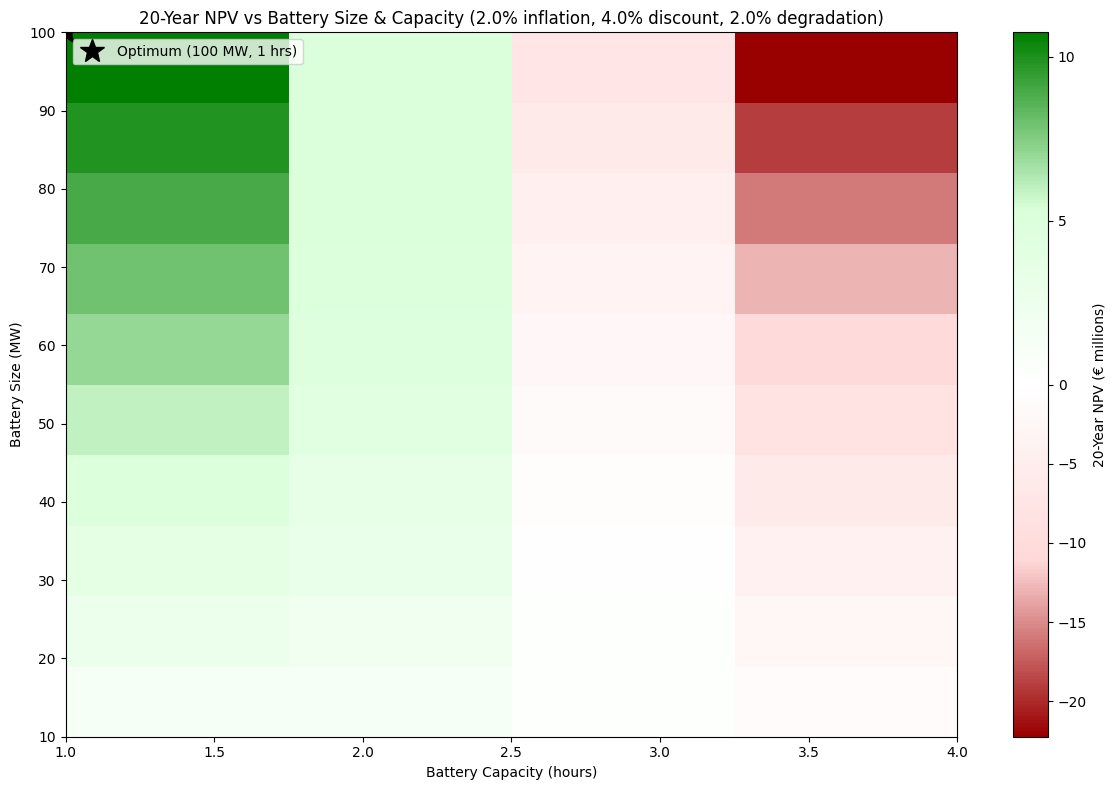

In [293]:
# === Optimise Batt_Size and Batt_Cap to maximise 20-Year NPV ===

import itertools
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

def simulate_npv(Batt_Size_val, Batt_Cap_val):
    """Run the battery simulation and return 20-year NPV."""
    Batt_Loss_l    = (1 - RTE) / 2
    oml_l          = 1 - Batt_Loss_l
    Max_Charge_l   = Batt_Size_val * Batt_Cap_val
    Min_C_l        = Max_Charge_l * min_charge
    Batt_Pow_l     = Batt_Size_val
    init_c_l       = init_charge * Max_Charge_l
    half_MIC_l     = MIC / 2

    # Pre-compute day-ahead grid charging schedule for this battery size
    if IncludeArbitrage:
        _ex_l  = df['Excess'].values
        _con_l = df['Constraints'].values.copy()
        if not IncludeCurtailment:
            _con_l[:] = 0.0
        _h_l    = df.index.hour.values
        sched_l = compute_grid_charge_schedule(
            Max_Charge_l, Min_C_l, Batt_Pow_l, oml_l,
            _ex_l, _con_l, _h_l, price_arr
        )
    else:
        sched_l = np.zeros(len(rem_load_arr))

    n_l = len(rem_load_arr)
    prev_charge         = init_c_l
    discharge_revenue_l = 0.0
    grid_charge_cost_l  = 0.0
    charge_status_l     = np.zeros(n_l)
    max_discharge_l     = np.zeros(n_l)

    for i in range(n_l):
        rl   = rem_load_arr[i]
        ex   = excess_arr[i]
        ch   = charging_arr[i]
        exb  = exbased_arr[i]
        cmd1 = charge_cmd1_arr[i]
        dis  = discharging_arr[i]
        con  = constraints_arr[i]
        has_con = con > 0

        # Max discharge
        Max_dis = 0.0
        if not has_con and dis and prev_charge > Min_C_l:
            spare = prev_charge - Min_C_l
            Max_dis = min(spare, Batt_Pow_l, rl)
            if Max_dis < 0:
                Max_dis = 0.0
        max_discharge_l[i] = Max_dis

        # Max charge (curtailment / time-based / excess)
        Max_C = 0.0
        if has_con and prev_charge < Max_Charge_l:
            avail = (Max_Charge_l - prev_charge) / oml_l
            Max_C = min(con, Batt_Pow_l, avail)
            if Max_C < 0:
                Max_C = 0.0
        elif cmd1 and prev_charge < Max_Charge_l:
            TCharge_Cap = min(
                (Max_Charge_l - (prev_charge - Max_dis)) / oml_l,
                abs(half_MIC_l - rl)
            ) * ch
            SCharge_Cap = min(
                (Max_Charge_l - prev_charge) / oml_l,
                ex
            ) * exb
            Max_C = min(TCharge_Cap + SCharge_Cap, Batt_Pow_l)
            if Max_C < 0:
                Max_C = 0.0

        # Additive grid charging from schedule
        gc = sched_l[i]
        if gc > 0 and prev_charge < Max_Charge_l:
            avail_space = (Max_Charge_l - prev_charge) / oml_l
            extra = max(min(gc, avail_space - Max_C), 0.0)
            Max_C += extra
            grid_charge_cost_l += extra * (price_arr[i] + grid_import_adder)

        # Accumulate discharge revenue (energy delivered at spot price)
        discharge_revenue_l += Max_dis * oml_l * price_arr[i]

        # Update SOC
        prev_charge = prev_charge + Max_C * oml_l - Max_dis
        charge_status_l[i] = prev_charge

    # DS3 FFR upward availability revenue (post-simulation, passive overlay)
    ds3_headroom_l  = np.maximum(0, charge_status_l - Min_C_l)
    ds3_avail_l     = np.minimum(Batt_Pow_l, ds3_headroom_l) - max_discharge_l
    ds3_avail_l     = np.maximum(0, ds3_avail_l)
    ds3_revenue_l   = (ds3_avail_l * DS3_FFR_rate).sum()

    # Annual battery revenue (excludes wind revenue — arbitrage margin + DS3)
    batt_opex_l    = Batt_Cap_val * Batt_Size_val * opex
    net_annual_rev = (discharge_revenue_l
                      - grid_charge_cost_l
                      + ds3_revenue_l
                      - batt_opex_l)

    batt_cost_l = Batt_Cap_val * Batt_Size_val * capex
    npv_val = -batt_cost_l + sum(
        net_annual_rev * (1 - degradation_rate)**yr * (1 + inflation_rate)**yr / (1 + discount_rate)**yr
        for yr in range(1, term + 1)
    )
    return npv_val


# --- Define search ranges ---
size_range = np.arange(10, 110, 10)        # MW  (5, 10, 15 … 100)
cap_range  = [1, 2, 3, 4]

# --- Grid search ---
best_npv  = -np.inf
best_size = None
best_cap  = None
results   = np.full((len(size_range), len(cap_range)), np.nan)

for i, sz in enumerate(size_range):
    for j, cp in enumerate(cap_range):
        npv_val = simulate_npv(sz, cp)
        results[i, j] = npv_val
        if npv_val > best_npv:
            best_npv  = npv_val
            best_size = sz
            best_cap  = cp

print(f"Optimal Batt_Size: {best_size} MW")
print(f"Optimal Batt_Cap:  {best_cap} hrs")
print(f"Maximum 20-Year NPV: €{best_npv:,.0f}")
print(f"Battery Cost: €{best_size * best_cap * capex:,.0f}")

# --- Custom red-white-green colormap centred at zero ---
red_green_cmap = LinearSegmentedColormap.from_list(
    'RedGreen',
    [(0.6, 0, 0), (1, 0.85, 0.85), (1, 1, 1), (0.85, 1, 0.85), (0, 0.5, 0)],
    N=256
)

results_M = results / 1e6
vmin, vmax = np.nanmin(results_M), np.nanmax(results_M)

if vmin < 0 < vmax:
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
elif vmin >= 0:
    norm = TwoSlopeNorm(vmin=-0.01, vcenter=0, vmax=vmax)
else:
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=0.01)

# --- Heatmap ---
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(results_M, origin='lower', aspect='auto',
               extent=[cap_range[0], cap_range[-1], size_range[0], size_range[-1]],
               cmap=red_green_cmap, norm=norm)
cbar = fig.colorbar(im, ax=ax, label='20-Year NPV (€ millions)')
ax.set_xlabel('Battery Capacity (hours)')
ax.set_ylabel('Battery Size (MW)')
ax.set_title(f'{term}-Year NPV vs Battery Size & Capacity ({inflation_rate*100:.1f}% inflation, '
             f'{discount_rate*100:.1f}% discount, {degradation_rate*100:.1f}% degradation)')
ax.plot(best_cap, best_size, 'k*', markersize=18,
        label=f'Optimum ({best_size} MW, {best_cap} hrs)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()